### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

### Reading the Dataset

In [3]:
df = pd.read_csv('data/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.shape

(2200, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [6]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

### Univariate Analysis

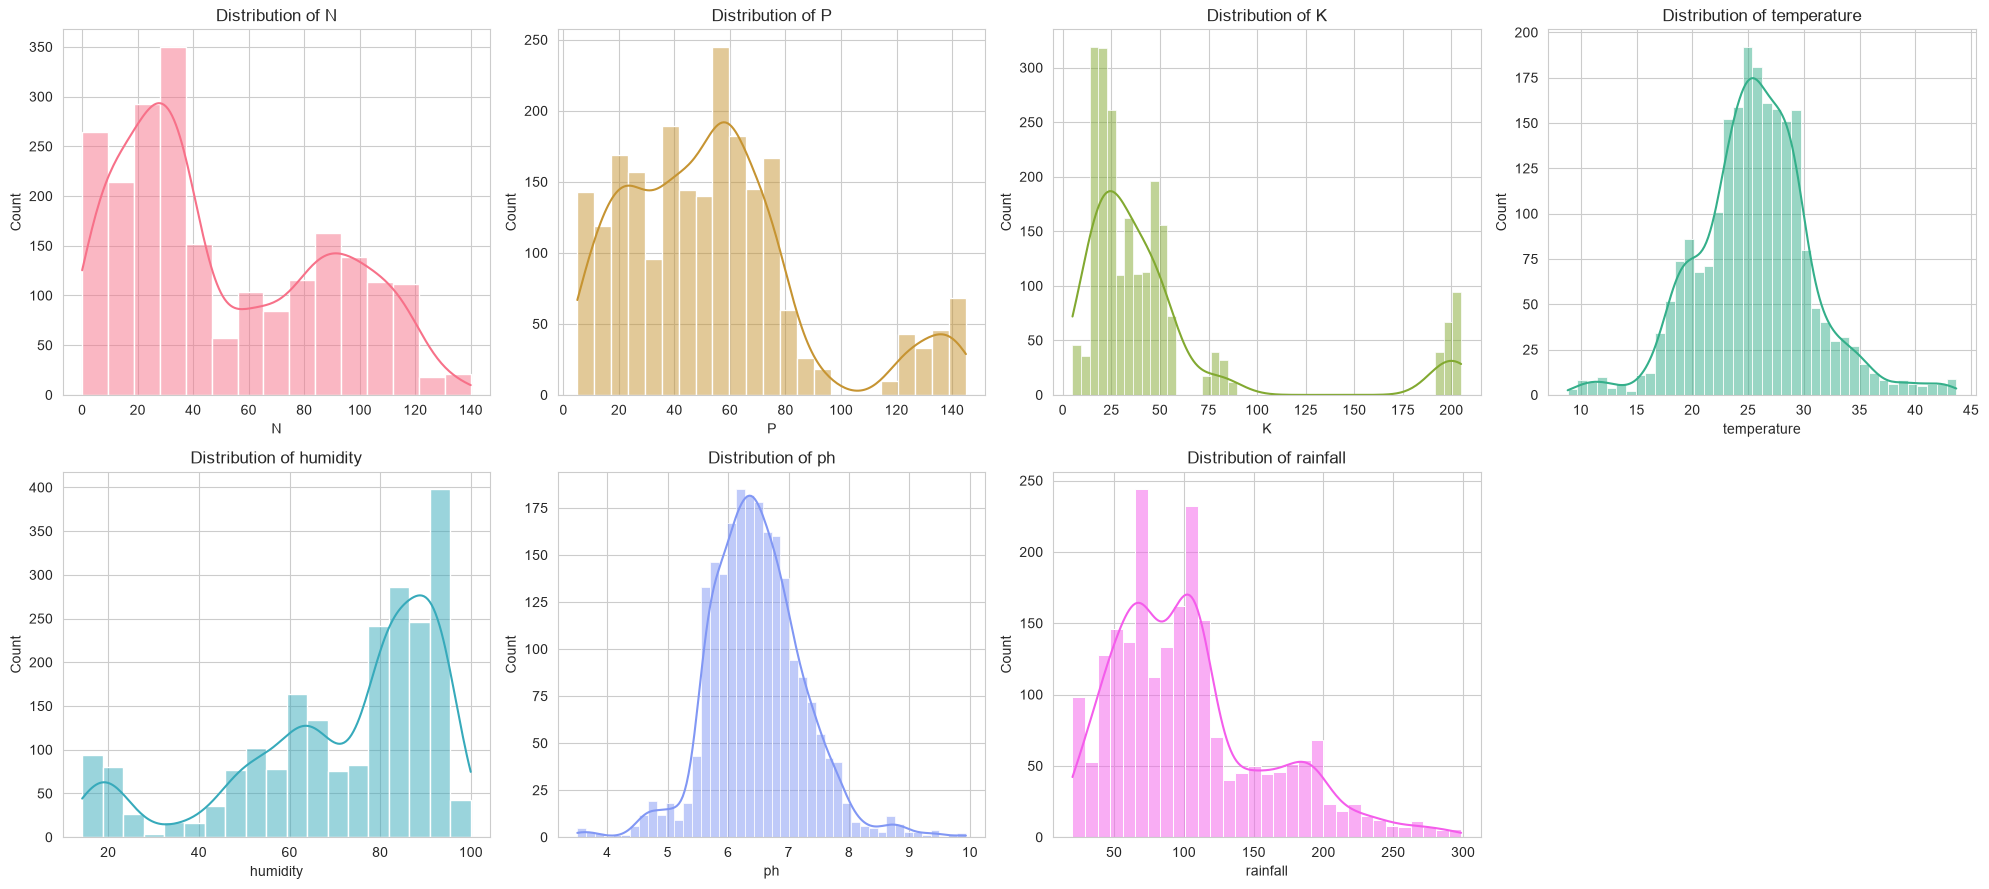

In [9]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette('husl', 7)[i])
    axes[i].set_title(f'Distribution of {col}')
axes[7].axis('off')
plt.tight_layout()
plt.show()

### Bivariate Analysis

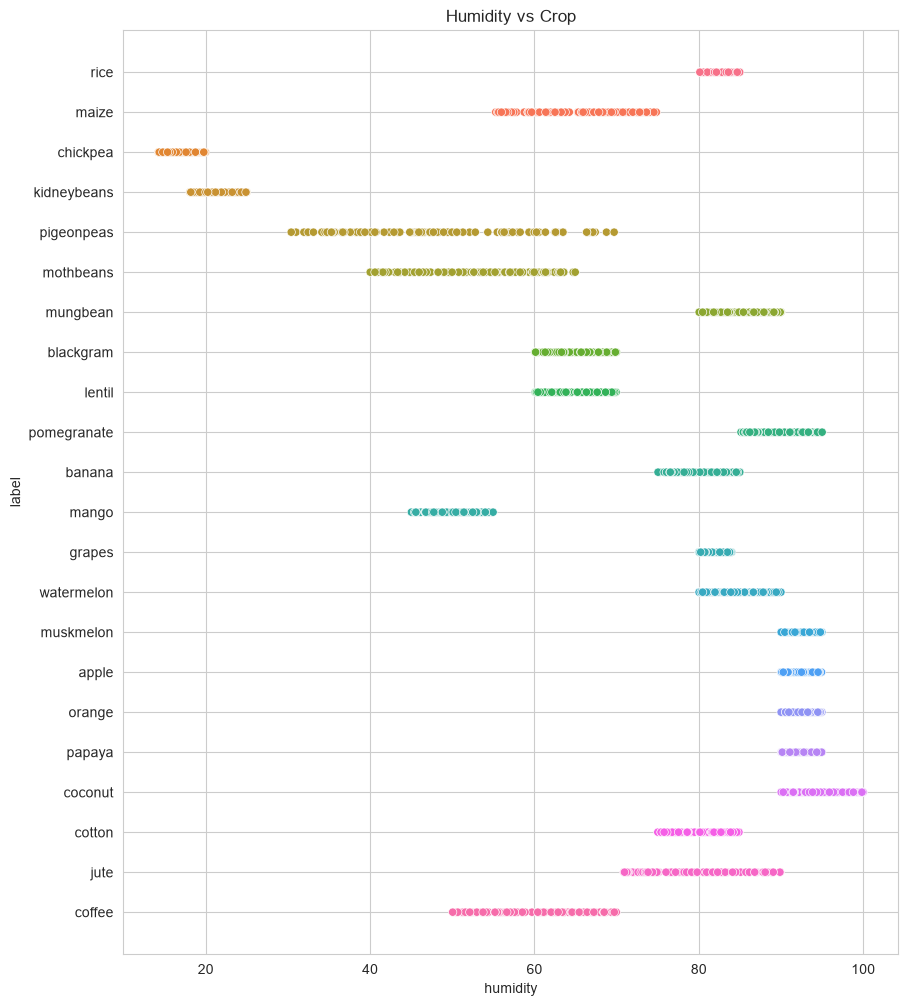

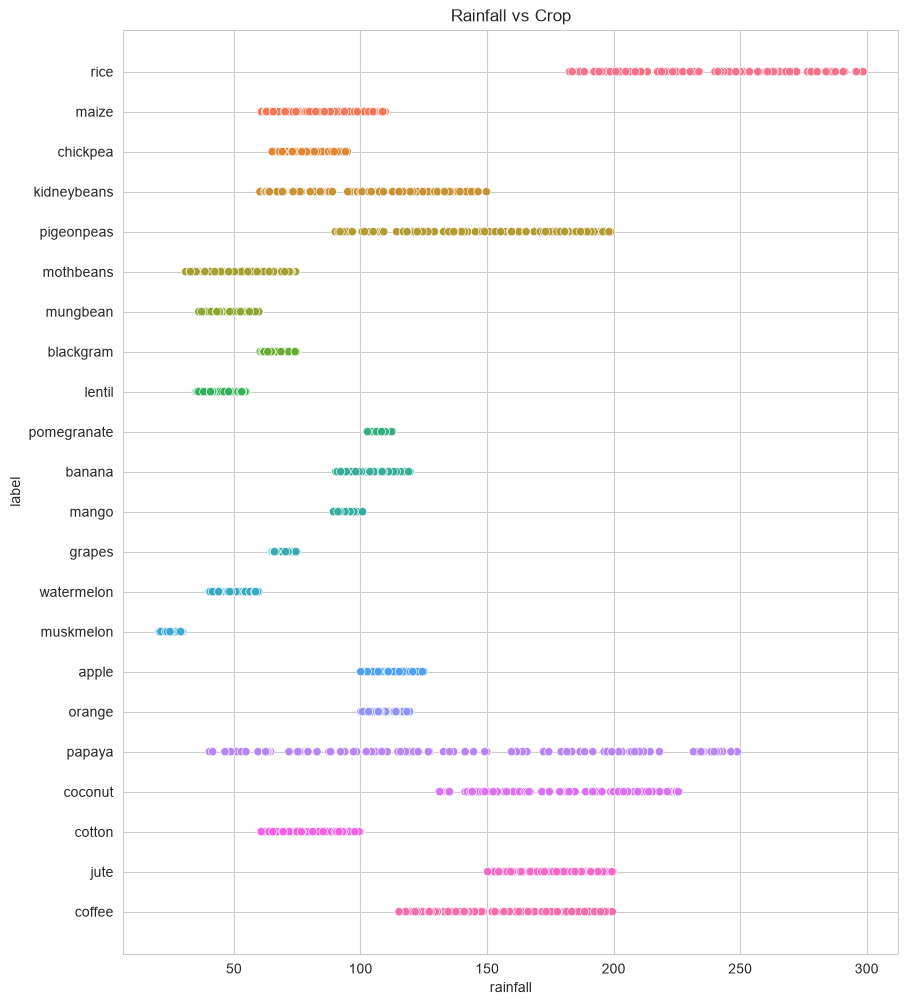

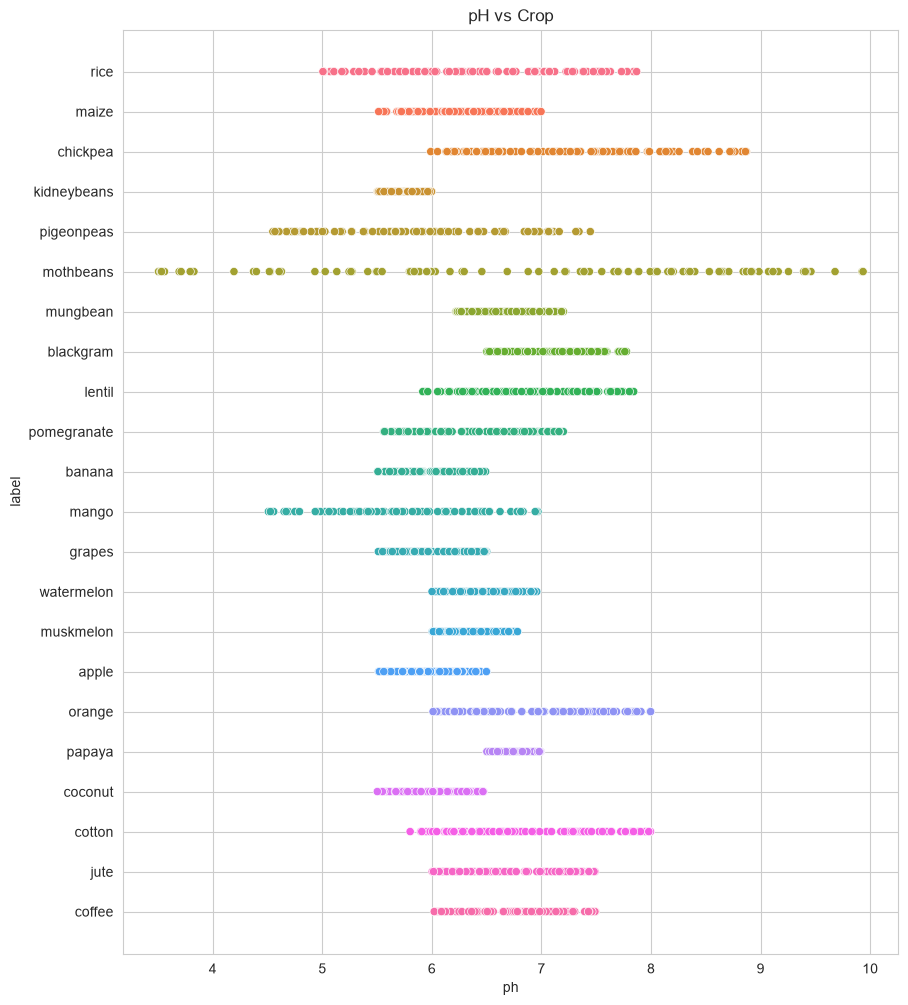

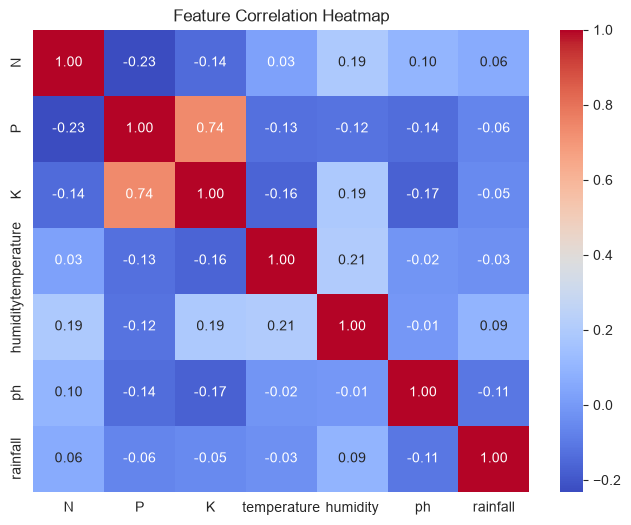

In [26]:
# Looking at relationships between pairs of features — and between each feature and the crop label

plt.figure(figsize=(10, 12))
sns.scatterplot(x=df['humidity'], y=df['label'], hue=df['label'], legend=False, palette='husl')
plt.title('Humidity vs Crop')
plt.show()

plt.figure(figsize=(10, 12))
sns.scatterplot(x=df['rainfall'], y=df['label'], hue=df['label'], legend=False, palette='husl')
plt.title('Rainfall vs Crop')
plt.show()

plt.figure(figsize=(10, 12))
sns.scatterplot(x=df['ph'], y=df['label'], hue=df['label'], legend=False, palette='husl')
plt.title('pH vs Crop')
plt.show()

# Correlation between numeric features (feature vs feature, not vs label)
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Multivariate Analysis

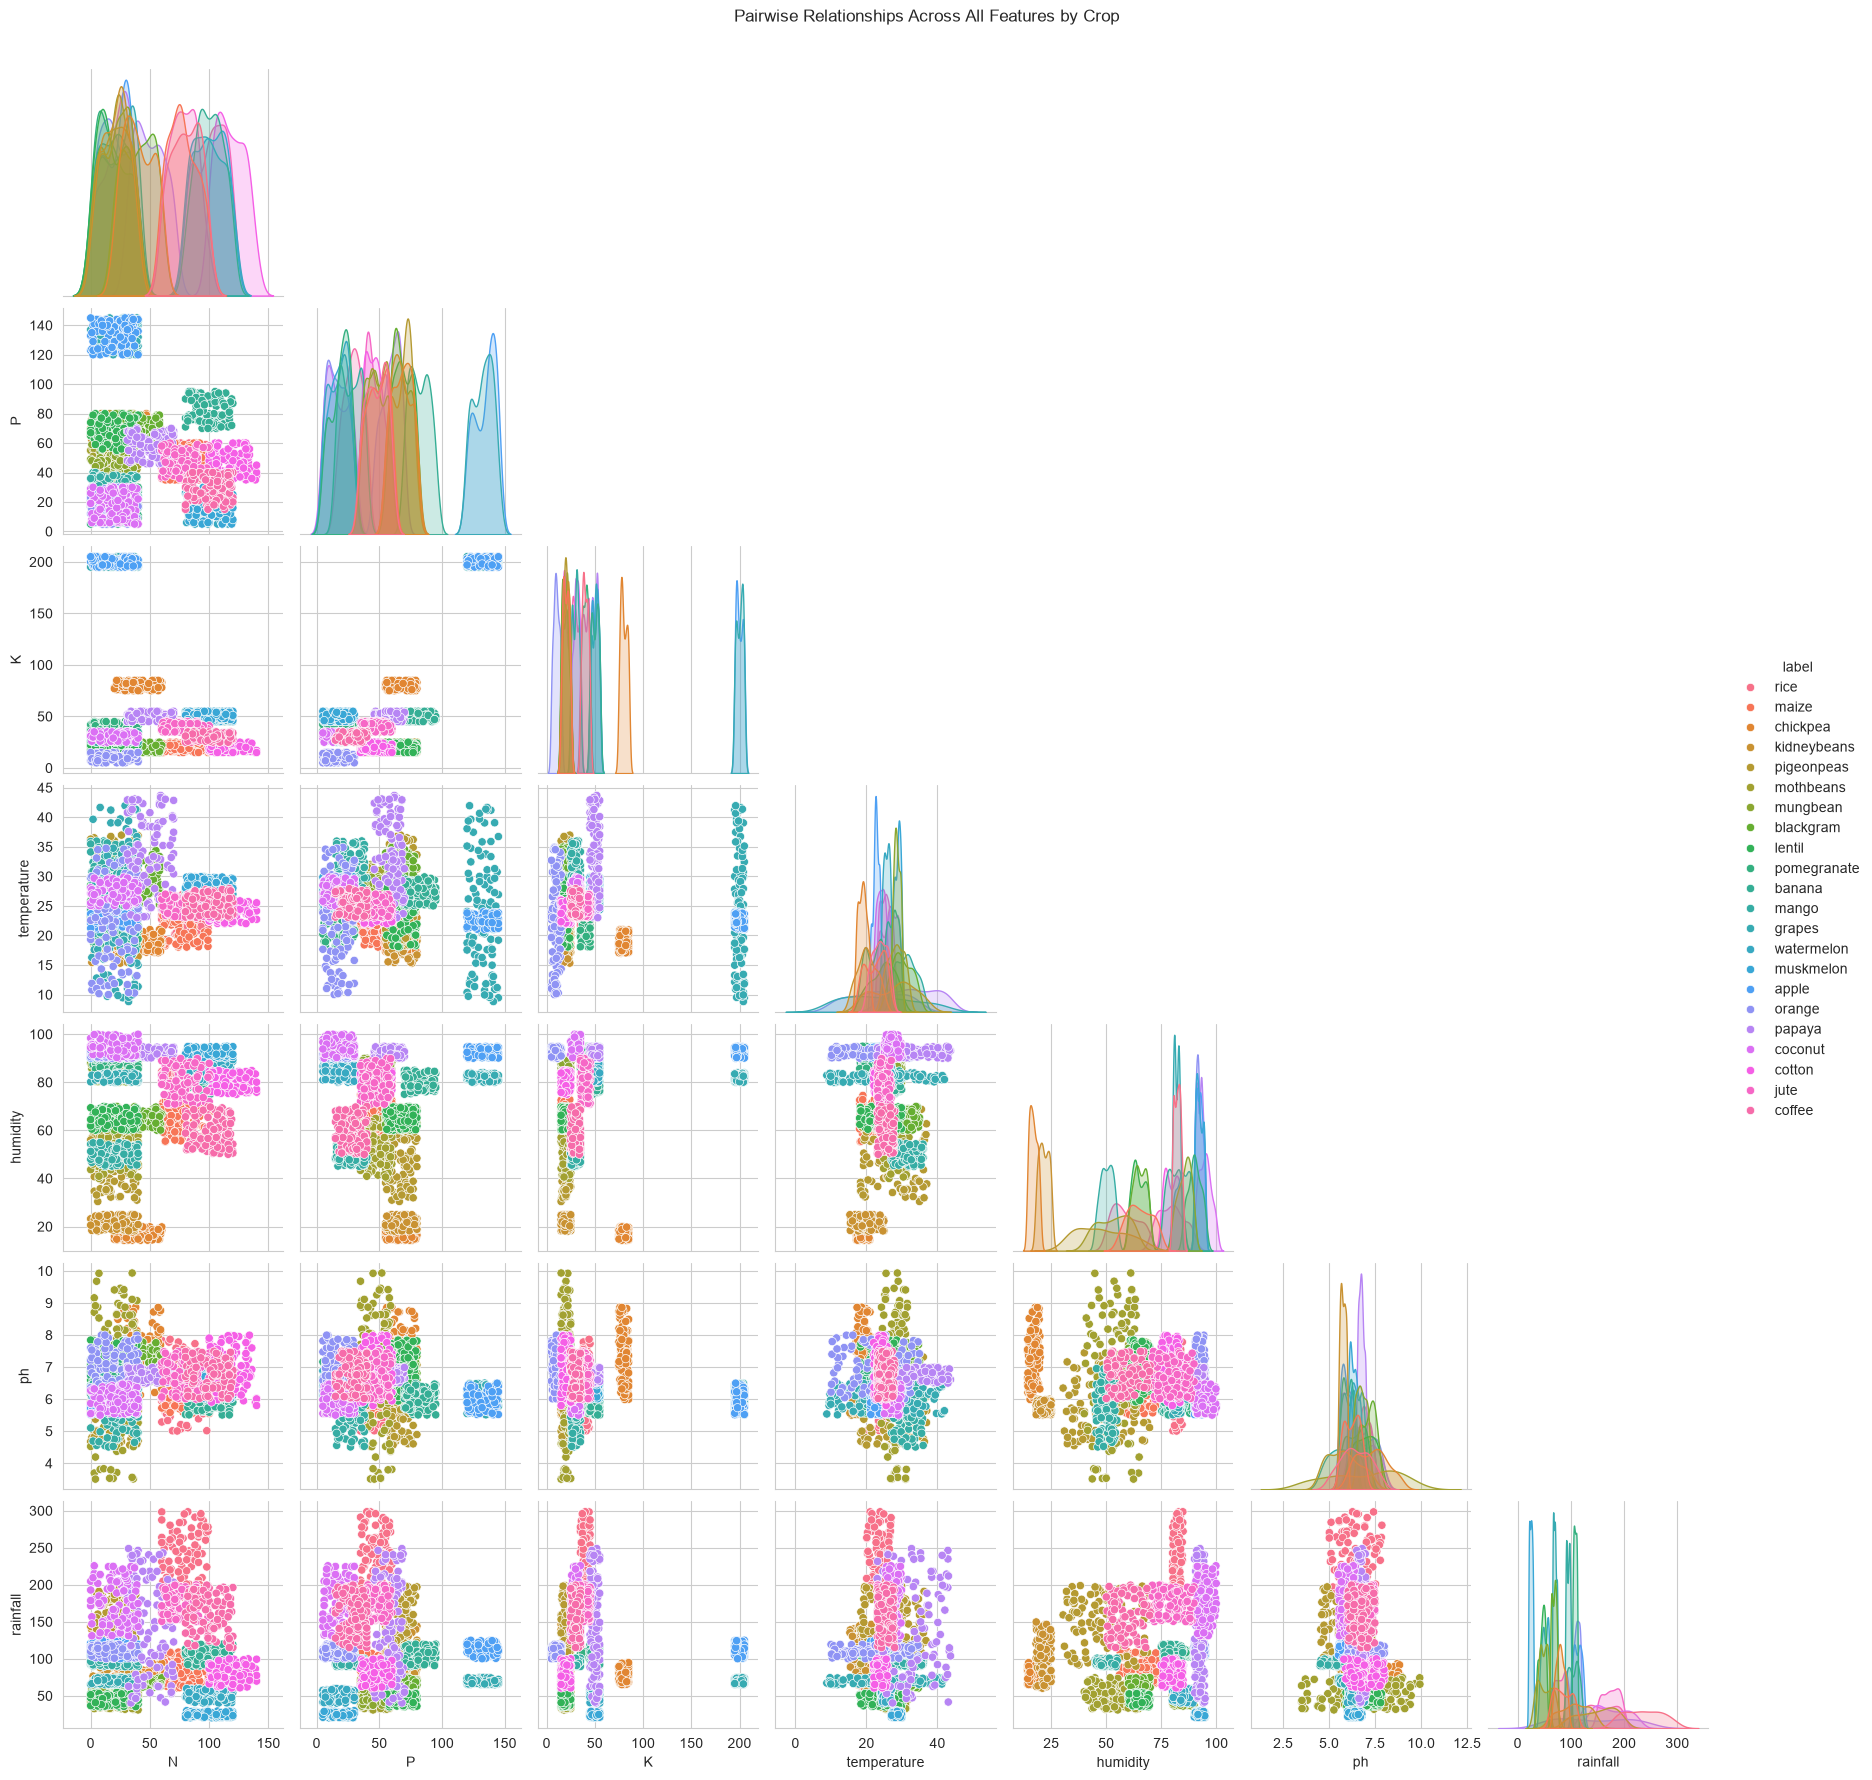

In [27]:
# Studying relationships among multiple features simultaneously

sns.pairplot(df, hue='label', diag_kind='kde', palette='husl', corner=True)
plt.suptitle('Pairwise Relationships Across All Features by Crop', y=1.02)
plt.show()

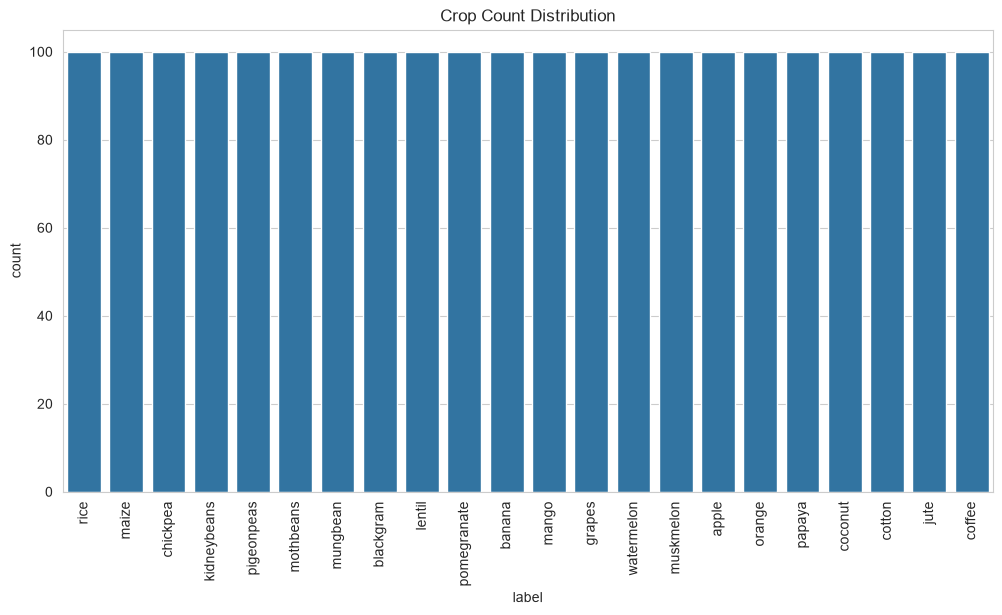

In [12]:
# Countplot to confirm class balance across the target
plt.figure(figsize=(12, 6))
sns.countplot(x=df['label'])
plt.xticks(rotation=90)
plt.title('Crop Count Distribution')
plt.show()

C:\Users\WIN 11\AppData\Local\Temp\ipykernel_22240\289999666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette='husl')
C:\Users\WIN 11\AppData\Local\Temp\ipykernel_22240\289999666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette='husl')
C:\Users\WIN 11\AppData\Local\Temp\ipykernel_22240\289999666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette='husl')
C:\Users\WIN 11\AppData\Local\Temp\ipykerne

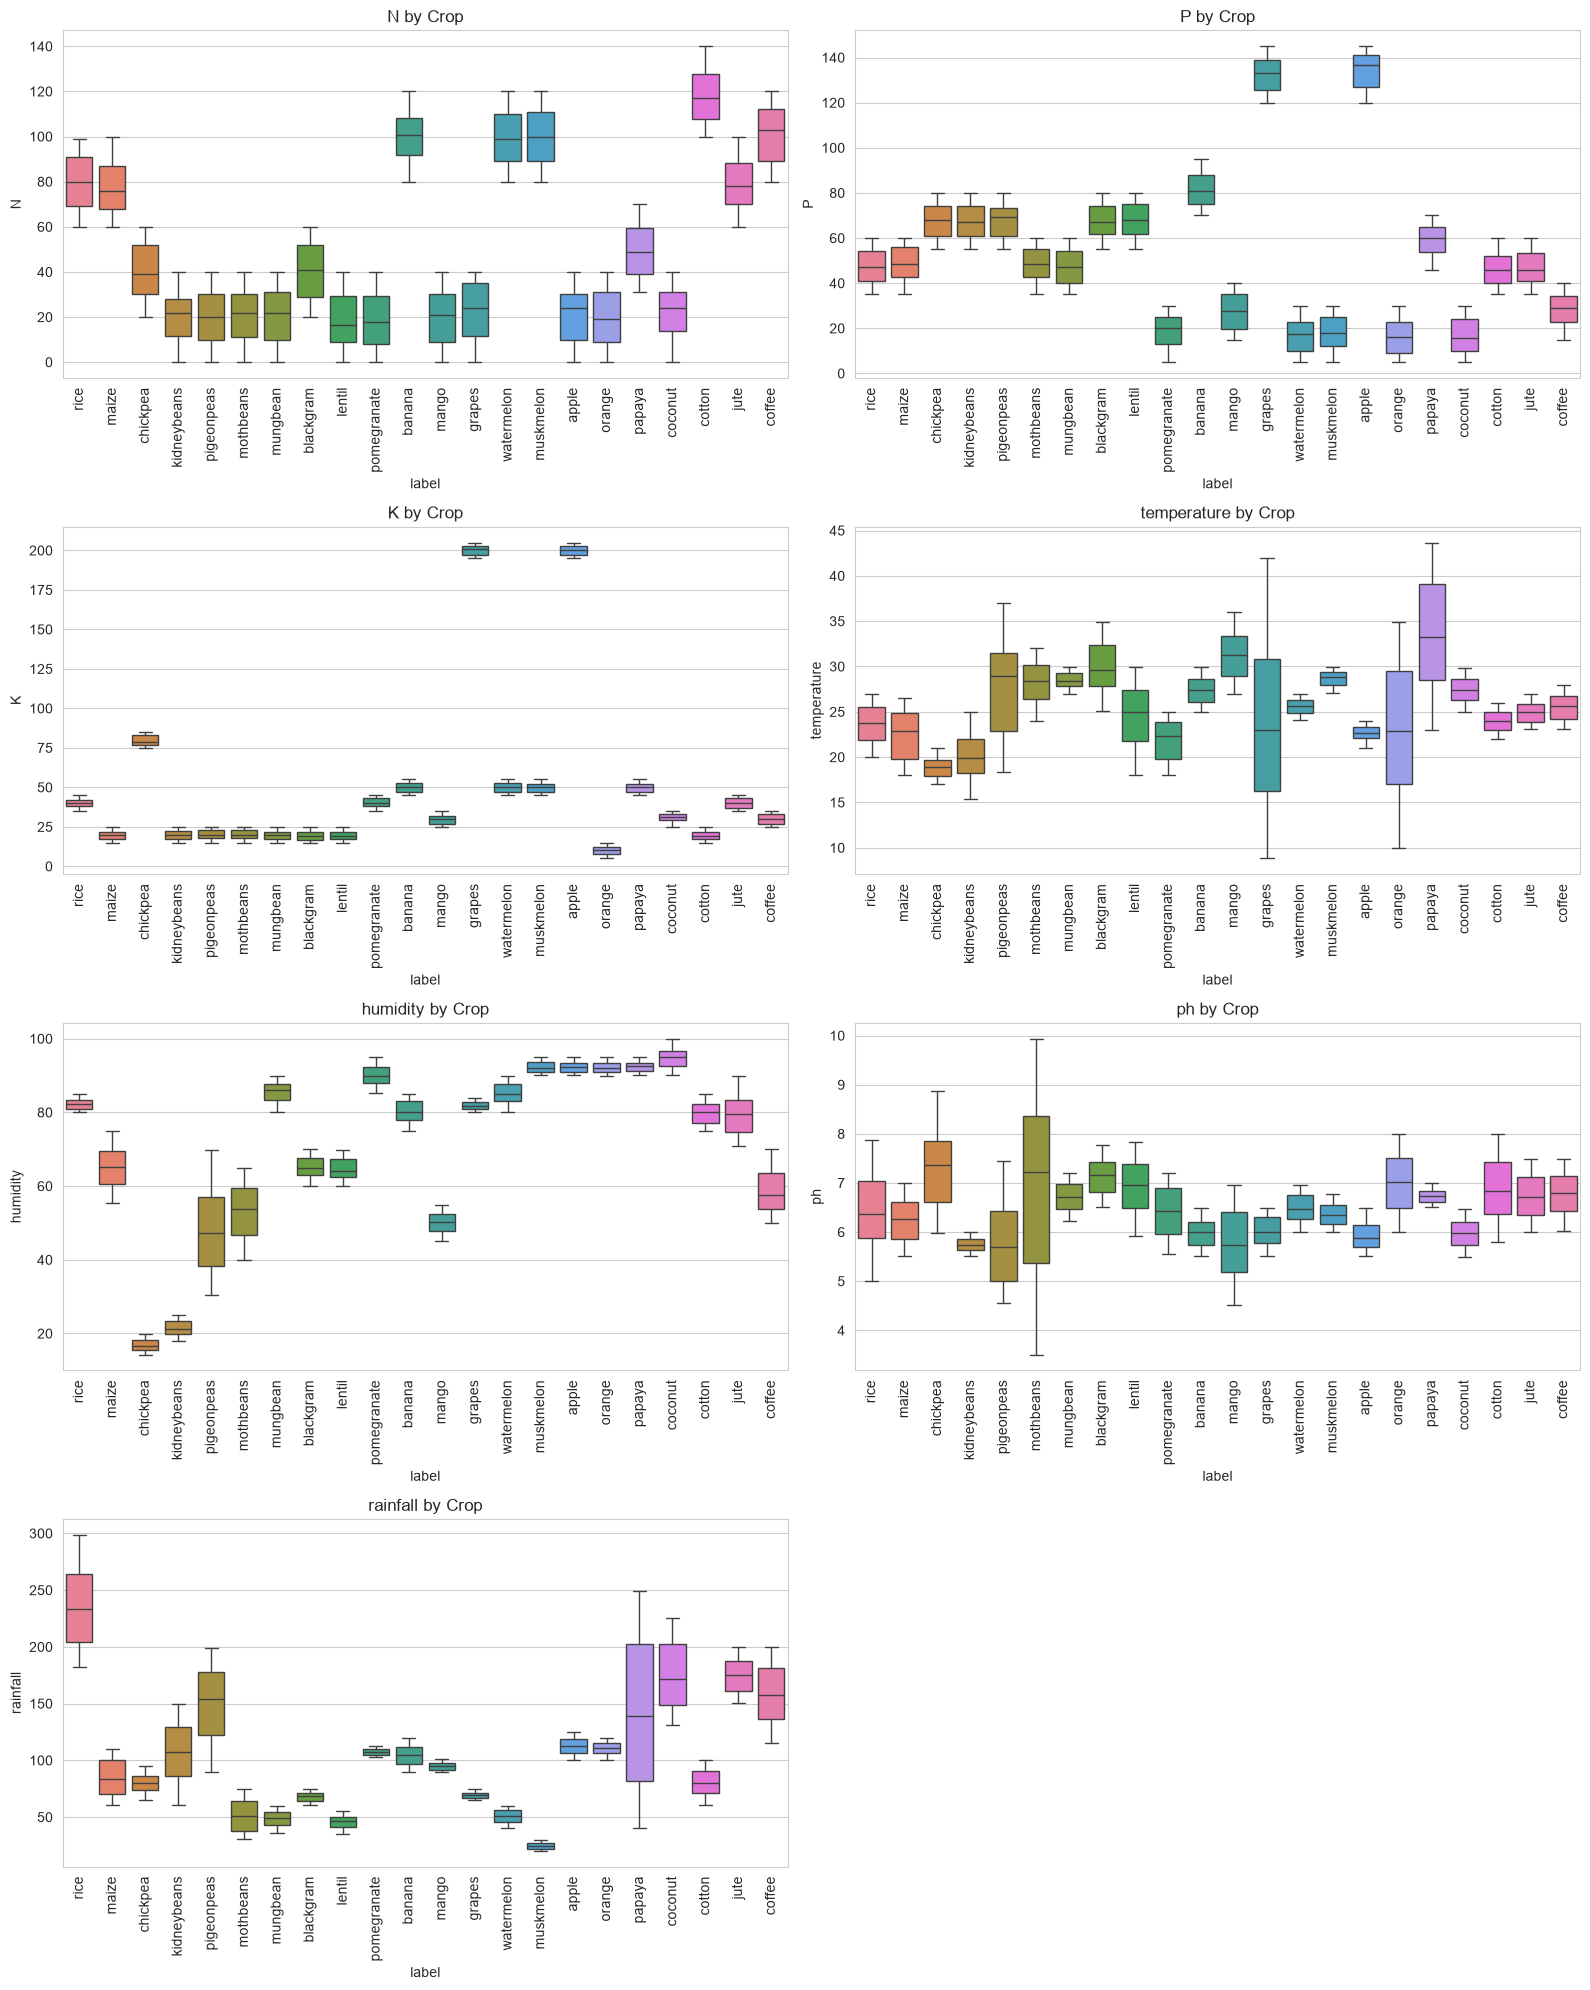

In [13]:
# Boxplots of each feature grouped by label — shows spread/outliers per crop, not just overall
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette='husl')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_title(f'{col} by Crop')
axes[7].axis('off')
plt.tight_layout()
plt.show()

### Data Pre-processing

In [28]:
#  Null check 
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [17]:
# -Outlier detection (IQR method) 
def count_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return df[(df[col] < lower) | (df[col] > upper)].shape[0]

for col in features:
    print(col, count_outliers(col))

N 0
P 138
K 200
temperature 86
humidity 30
ph 57
rainfall 100


In [18]:
# Extract seasonal crop information 
print("Summer crops")
print(df[(df['temperature']>30) & (df['humidity']>50)]['label'].unique())
print("-"*50)

print("Winter crops")
print(df[(df['temperature']<20) & (df['humidity']>30)]['label'].unique())
print("-"*50)

print("Rainy crops")
print(df[(df['rainfall']>200) & (df['humidity']>50)]['label'].unique())
print("-"*50)

Summer crops
<StringArray>
['pigeonpeas', 'mothbeans', 'blackgram', 'mango', 'grapes', 'orange',
 'papaya']
Length: 7, dtype: str
--------------------------------------------------
Winter crops
<StringArray>
['maize', 'pigeonpeas', 'lentil', 'pomegranate', 'grapes', 'orange']
Length: 6, dtype: str
--------------------------------------------------
Rainy crops
<StringArray>
['rice', 'papaya', 'coconut']
Length: 3, dtype: str
--------------------------------------------------


In [23]:
# Train/test split 

from sklearn.model_selection import train_test_split

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(1760, 7) (440, 7)


### K-Means Clustering

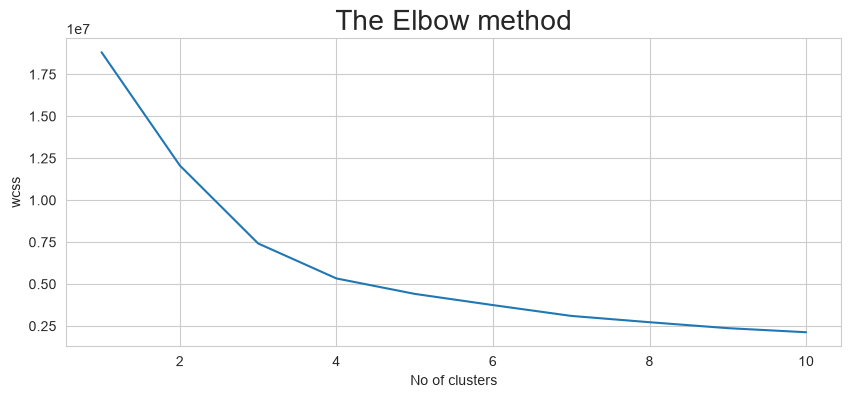

In [29]:
# Elbow method to find optimal number of clusters
plt.rcParams['figure.figsize'] = (10,4)
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init="k-means++", max_iter=300, n_init=10, random_state=0)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)
plt.title("The Elbow method", fontsize=20)
plt.xlabel("No of clusters")
plt.ylabel("wcss")
plt.show()

In [25]:
# Training the model with k=4
km = KMeans(n_clusters=4, init="k-means++", max_iter=300, n_init=10, random_state=0)
y_means = km.fit_predict(X)

a = df['label']
y_means = pd.DataFrame(y_means)
z = pd.concat([y_means, a], axis=1)
z = z.rename(columns={0: 'cluster'})

print("Lets check the results after applying the K-Means clustering analysis\n")
print("Crops in First cluster:", z[z['cluster']==0]['label'].unique())
print("-"*50)
print("Crops in Second cluster:", z[z['cluster']==1]['label'].unique())
print("-"*50)
print("Crops in Third cluster:", z[z['cluster']==2]['label'].unique())
print("-"*50)
print("Crops in Fourth cluster:", z[z['cluster']==3]['label'].unique())

Lets check the results after applying the K-Means clustering analysis

Crops in First cluster: <StringArray>
['grapes', 'apple']
Length: 2, dtype: str
--------------------------------------------------
Crops in Second cluster: <StringArray>
[      'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',   'mothbeans',
    'mungbean',   'blackgram',      'lentil', 'pomegranate',       'mango',
      'orange',      'papaya',     'coconut']
Length: 13, dtype: str
--------------------------------------------------
Crops in Third cluster: <StringArray>
['maize', 'banana', 'watermelon', 'muskmelon', 'papaya', 'cotton', 'coffee']
Length: 7, dtype: str
--------------------------------------------------
Crops in Fourth cluster: <StringArray>
['rice', 'pigeonpeas', 'papaya', 'coconut', 'jute', 'coffee']
Length: 6, dtype: str


### Logistic Regression 


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Scale features — matters here since N (0-140), ph (3.5-10), rainfall (20-300) 
# are on very different scales, and Logistic Regression's gradient-based solver 
# converges faster and more reliably on scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9727272727272728
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        2

### Saving the model

In [31]:
import pickle

with open('crop_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Also save the scaler — you'll need it to transform any new user input 
# the same way before predicting, or predictions will be wrong
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)